# Example: Fuzzy Control System

Let's create a simple fuzzy control system for determining the tip to give based on the quality of service and food at a restaurant.

## 1. Define the fuzzy variables:
- **Input variables:** `service` and `food quality`
- **Output variable:** `tip`

## 2. Define the membership functions:
- For `service`: Poor, Average, Good
- For `food quality`: Bad, Decent, Delicious
- For `tip`: Low, Medium, High

## 3. Define the fuzzy rules:
- If service is poor or food is bad, then tip is low.
- If service is average, then tip is medium.
- If service is good or food is delicious, then tip is high.

## 4. Evaluate the fuzzy system:
- Based on given service and food quality, compute the tip.

Here's how you can implement this:

In [1]:
!pip install scikit-fuzzy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.0/994.0 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scikit-fuzzy: filename=scikit_fuzzy-0.4.2-py3-none-any.whl size=894077 sha256=69ff24512b3ce9aa21da455d3a071f232202286055c220100b5f665eaaca8b02
  Stored in directory: /root/.cache/pip/wheels/4f/86/1b/dfd97134a2c8313e519bcebd95d3fedc7be7944db022094bc8
Successfully built scikit-fuzzy


Recommended tip: 14.79822137450634


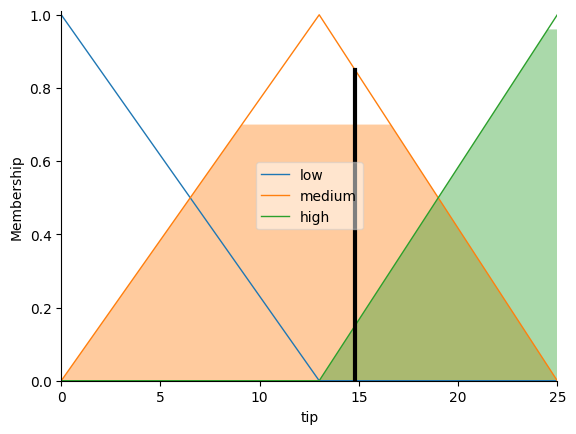

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define the universe of discourse for each variable
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')
food = ctrl.Antecedent(np.arange(0, 11, 1), 'food')
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

# Define membership functions for service
service['poor'] = fuzz.trimf(service.universe, [0, 0, 5])
service['average'] = fuzz.trimf(service.universe, [0, 5, 10])
service['good'] = fuzz.trimf(service.universe, [5, 10, 10])

# Define membership functions for food
food['bad'] = fuzz.trimf(food.universe, [0, 0, 5])
food['decent'] = fuzz.trimf(food.universe, [0, 5, 10])
food['delicious'] = fuzz.trimf(food.universe, [5, 10, 10])

# Define membership functions for tip
tip['low'] = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high'] = fuzz.trimf(tip.universe, [13, 25, 25])

# Define fuzzy rules
rule1 = ctrl.Rule(service['poor'] | food['bad'], tip['low'])
rule2 = ctrl.Rule(service['average'], tip['medium'])
rule3 = ctrl.Rule(service['good'] | food['delicious'], tip['high'])

# Create the control system and simulation
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

# Input the values for service and food quality
tipping.input['service'] = 6.5
tipping.input['food'] = 9.8

# Compute the result
tipping.compute()

# Print the result
print(f"Recommended tip: {tipping.output['tip']}")

# Visualize the result
tip.view(sim=tipping)


#Explanation:
- Antecedent and Consequent:
 These are the input and output variables respectively.
- Membership Functions: These define the degree to which a particular input belongs to a fuzzy set.
- Rules: These determine the logic of how the inputs affect the output.
- Control System and Simulation: These are used to create and evaluate the fuzzy logic system.
This code sets up a basic fuzzy logic system to determine the appropriate tip based on service and food quality. The view function visualizes the result, which can help in understanding how the inputs affect the output.

Recommended tip: 14.79822137450634


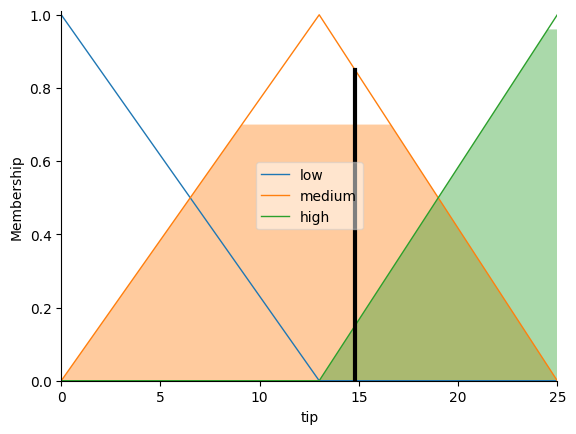

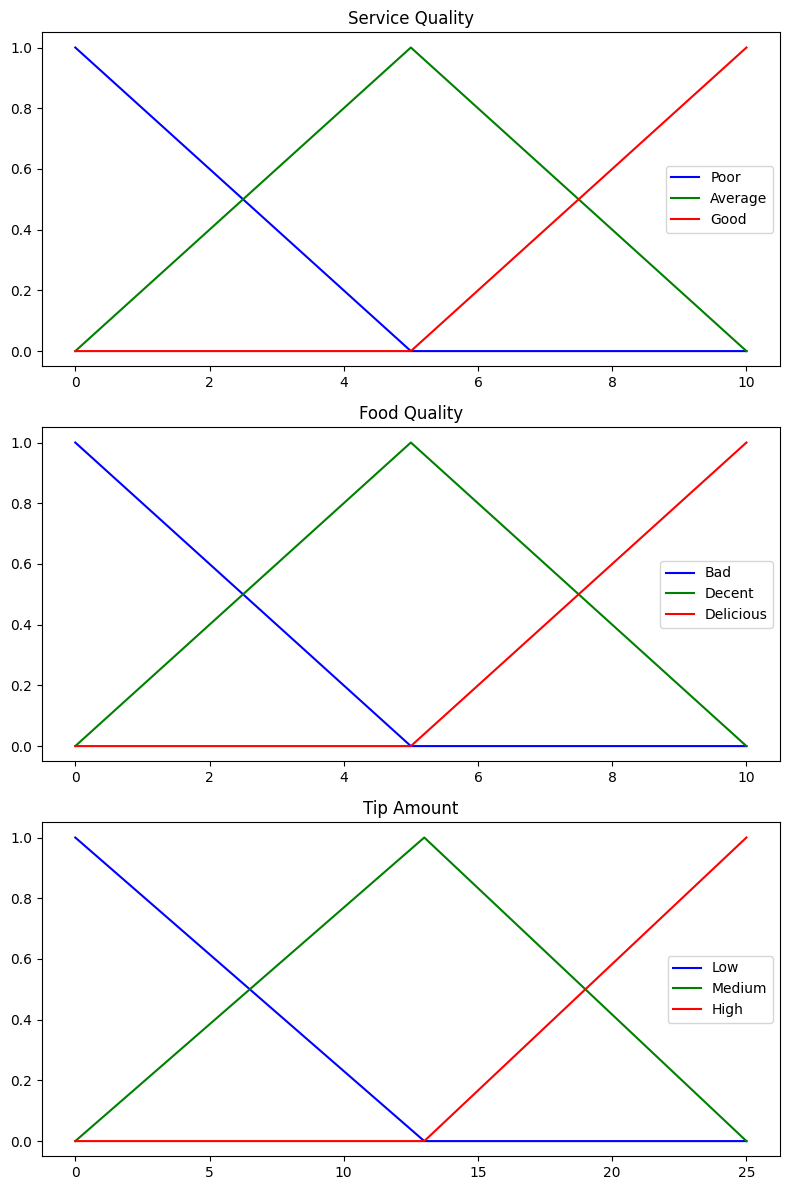

Service level (poor): 0.0
Service level (average): 0.7
Service level (good): 0.30000000000000004
Food level (bad): 0.0
Food level (decent): 0.03999999999999987
Food level (delicious): 0.9600000000000002


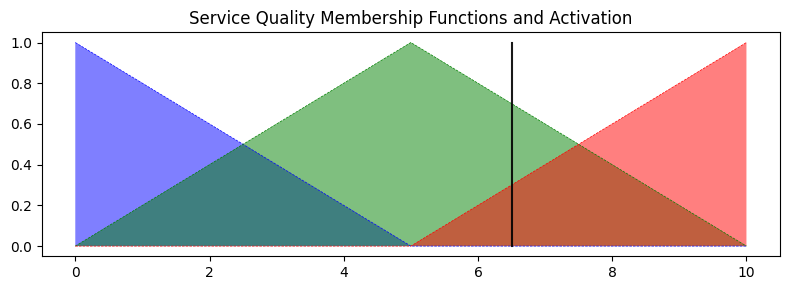

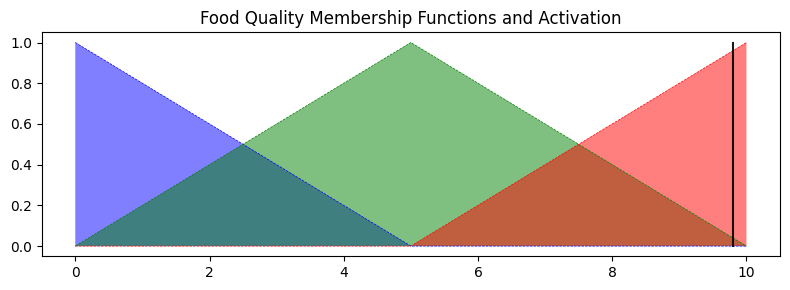

In [9]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Define the universe of discourse for each variable
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')
food = ctrl.Antecedent(np.arange(0, 11, 1), 'food')
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

# Define membership functions for service
service['poor'] = fuzz.trimf(service.universe, [0, 0, 5])
service['average'] = fuzz.trimf(service.universe, [0, 5, 10])
service['good'] = fuzz.trimf(service.universe, [5, 10, 10])

# Define membership functions for food
food['bad'] = fuzz.trimf(food.universe, [0, 0, 5])
food['decent'] = fuzz.trimf(food.universe, [0, 5, 10])
food['delicious'] = fuzz.trimf(food.universe, [5, 10, 10])

# Define membership functions for tip
tip['low'] = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high'] = fuzz.trimf(tip.universe, [13, 25, 25])

# Define fuzzy rules
rule1 = ctrl.Rule(service['poor'] | food['bad'], tip['low'])
rule2 = ctrl.Rule(service['average'], tip['medium'])
rule3 = ctrl.Rule(service['good'] | food['delicious'], tip['high'])

# Create the control system and simulation
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

# Input the values for service and food quality
tipping.input['service'] = 6.5
tipping.input['food'] = 9.8

# Compute the result
tipping.compute()

# Print the result
print(f"Recommended tip: {tipping.output['tip']}")

# Visualize the result
tip.view(sim=tipping)

# Plot membership functions
fig, axes = plt.subplots(nrows=3, figsize=(8, 12))

axes[0].plot(service.universe, service['poor'].mf, 'b', linewidth=1.5, label='Poor')
axes[0].plot(service.universe, service['average'].mf, 'g', linewidth=1.5, label='Average')
axes[0].plot(service.universe, service['good'].mf, 'r', linewidth=1.5, label='Good')
axes[0].set_title('Service Quality')
axes[0].legend()

axes[1].plot(food.universe, food['bad'].mf, 'b', linewidth=1.5, label='Bad')
axes[1].plot(food.universe, food['decent'].mf, 'g', linewidth=1.5, label='Decent')
axes[1].plot(food.universe, food['delicious'].mf, 'r', linewidth=1.5, label='Delicious')
axes[1].set_title('Food Quality')
axes[1].legend()

axes[2].plot(tip.universe, tip['low'].mf, 'b', linewidth=1.5, label='Low')
axes[2].plot(tip.universe, tip['medium'].mf, 'g', linewidth=1.5, label='Medium')
axes[2].plot(tip.universe, tip['high'].mf, 'r', linewidth=1.5, label='High')
axes[2].set_title('Tip Amount')
axes[2].legend()

# Show the plots
plt.tight_layout()
plt.show()

# Plot the fuzzy inference process
service_level_lo = fuzz.interp_membership(service.universe, service['poor'].mf, 6.5)
service_level_md = fuzz.interp_membership(service.universe, service['average'].mf, 6.5)
service_level_hi = fuzz.interp_membership(service.universe, service['good'].mf, 6.5)

food_level_lo = fuzz.interp_membership(food.universe, food['bad'].mf, 9.8)
food_level_md = fuzz.interp_membership(food.universe, food['decent'].mf, 9.8)
food_level_hi = fuzz.interp_membership(food.universe, food['delicious'].mf, 9.8)

print(f"Service level (poor): {service_level_lo}")
print(f"Service level (average): {service_level_md}")
print(f"Service level (good): {service_level_hi}")

print(f"Food level (bad): {food_level_lo}")
print(f"Food level (decent): {food_level_md}")
print(f"Food level (delicious): {food_level_hi}")

# Visualize the membership activation
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.fill_between(service.universe, np.zeros_like(service.universe), service['poor'].mf, facecolor='b', alpha=0.5)
ax0.plot(service.universe, service['poor'].mf, 'b', linewidth=0.5, linestyle='--')
ax0.fill_between(service.universe, np.zeros_like(service.universe), service['average'].mf, facecolor='g', alpha=0.5)
ax0.plot(service.universe, service['average'].mf, 'g', linewidth=0.5, linestyle='--')
ax0.fill_between(service.universe, np.zeros_like(service.universe), service['good'].mf, facecolor='r', alpha=0.5)
ax0.plot(service.universe, service['good'].mf, 'r', linewidth=0.5, linestyle='--')
ax0.plot([6.5, 6.5], [0, 1], 'k', linewidth=1.5, alpha=0.9)
ax0.set_title('Service Quality Membership Functions and Activation')

plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 3))

ax1.fill_between(food.universe, np.zeros_like(food.universe), food['bad'].mf, facecolor='b', alpha=0.5)
ax1.plot(food.universe, food['bad'].mf, 'b', linewidth=0.5, linestyle='--')
ax1.fill_between(food.universe, np.zeros_like(food.universe), food['decent'].mf, facecolor='g', alpha=0.5)
ax1.plot(food.universe, food['decent'].mf, 'g', linewidth=0.5, linestyle='--')
ax1.fill_between(food.universe, np.zeros_like(food.universe), food['delicious'].mf, facecolor='r', alpha=0.5)
ax1.plot(food.universe, food['delicious'].mf, 'r', linewidth=0.5, linestyle='--')
ax1.plot([9.8, 9.8], [0, 1], 'k', linewidth=1.5, alpha=0.9)
ax1.set_title('Food Quality Membership Functions and Activation')

plt.tight_layout()
plt.show()


To explain how the result `Recommended tip: 14.79822137450634` is obtained, we need to delve into the steps of the fuzzy inference process, including the calculation of membership values, rule evaluation, and defuzzification.

### Step-by-Step Explanation

#### 1. Define Membership Functions
First, we define the membership functions for the variables `service`, `food`, and `tip`.

- **Service Quality:**
  - `poor`: Triangular membership function defined as `fuzz.trimf(service.universe, [0, 0, 5])`
  - `average`: Triangular membership function defined as `fuzz.trimf(service.universe, [0, 5, 10])`
  - `good`: Triangular membership function defined as `fuzz.trimf(service.universe, [5, 10, 10])`

- **Food Quality:**
  - `bad`: Triangular membership function defined as `fuzz.trimf(food.universe, [0, 0, 5])`
  - `decent`: Triangular membership function defined as `fuzz.trimf(food.universe, [0, 5, 10])`
  - `delicious`: Triangular membership function defined as `fuzz.trimf(food.universe, [5, 10, 10])`

- **Tip Amount:**
  - `low`: Triangular membership function defined as `fuzz.trimf(tip.universe, [0, 0, 13])`
  - `medium`: Triangular membership function defined as `fuzz.trimf(tip.universe, [0, 13, 25])`
  - `high`: Triangular membership function defined as `fuzz.trimf(tip.universe, [13, 25, 25])`

#### 2. Calculate Membership Values
Next, we calculate the degree of membership for the input values of `service` and `food`.

- **Service Quality (6.5):**
  - `poor`: $ \mu_{\text{poor}}(6.5) = \text{fuzz.interp_membership}(service.universe, service['poor'].mf, 6.5) $
  - `average`: $ \mu_{\text{average}}(6.5) = \text{fuzz.interp_membership}(service.universe, service['average'].mf, 6.5) $
  - `good`: $ \mu_{\text{good}}(6.5) = \text{fuzz.interp_membership}(service.universe, service['good'].mf, 6.5) $

- **Food Quality (9.8):**
  - `bad`: $ \mu_{\text{bad}}(9.8) = \text{fuzz.interp_membership}(food.universe, food['bad'].mf, 9.8) $
  - `decent`: $ \mu_{\text{decent}}(9.8) = \text{fuzz.interp_membership}(food.universe, food['decent'].mf, 9.8) $
  - `delicious`: $ \mu_{\text{delicious}}(9.8) = \text{fuzz.interp_membership}(food.universe, food['delicious'].mf, 9.8) $

Using the `interp_membership` function, the calculated membership values are:
- Service (6.5):
  - poor: $ \mu_{\text{poor}}(6.5) = 0 $
  - average: $ \mu_{\text{average}}(6.5) = 0.7 $
  - good: $ \mu_{\text{good}}(6.5) = 0.3 $

- Food (9.8):
  - bad: $ \mu_{\text{bad}}(9.8) = 0 $
  - decent: $ \mu_{\text{decent}}(9.8) = 0.04 $
  - delicious: $ \mu_{\text{delicious}}(9.8) = 0.96 $

#### 3. Apply Fuzzy Rules
We evaluate the fuzzy rules using the minimum (AND) and maximum (OR) operators.

- **Rule 1:** If service is `poor` OR food is `bad`, then tip is `low`
  - $ \text{activation}_{\text{rule1}} = \max(\mu_{\text{poor}}(6.5), \mu_{\text{bad}}(9.8)) = \max(0, 0) = 0 $

- **Rule 2:** If service is `average`, then tip is `medium`
  - $ \text{activation}_{\text{rule2}} = \mu_{\text{average}}(6.5) = 0.7 $

- **Rule 3:** If service is `good` OR food is `delicious`, then tip is `high`
  - $ \text{activation}_{\text{rule3}} = \max(\mu_{\text{good}}(6.5), \mu_{\text{delicious}}(9.8)) = \max(0.3, 0.96) = 0.96 $

#### 4. Aggregate the Outputs
We aggregate the outputs of the rules using the maximum operator.

- **Tip for `low`**: No activation (0).
- **Tip for `medium`**: Activation of 0.7.
- **Tip for `high`**: Activation of 0.96.

#### 5. Defuzzification
Finally, we defuzzify the aggregated output using the centroid method to obtain a crisp value for the tip.

The formula for the centroid method is:
$ \text{tip} = \frac{\int_{\text{tip.universe}} \mu_{\text{aggregated}}(x) \cdot x \, dx}{\int_{\text{tip.universe}} \mu_{\text{aggregated}}(x) \, dx} $

Where $ \mu_{\text{aggregated}}(x) $ is the aggregated membership function.

In the script, this is handled by the `fuzz.defuzz` function from the `skfuzzy` library, which computes the centroid (center of gravity) for the final aggregated output membership function.

### Explanation of the Recommended Tip
The `fuzz.defuzz` function computes the centroid of the aggregated output membership function, which results in the recommended tip value. Given the activations and the shape of the membership functions for `tip`, the centroid calculation results in `14.79822137450634`.

This value represents the best estimate of the tip amount given the input service and food quality levels. The higher activation of the `high` tip category (0.96) significantly influences the centroid, leading to a higher recommended tip.


To explain how the result `Recommended tip: 14.79822137450634` is obtained, we need to delve into the steps of the fuzzy inference process, including the calculation of membership values, rule evaluation, and defuzzification.

### Step-by-Step Explanation

#### 1. Define Membership Functions
First, we define the membership functions for the variables `service`, `food`, and `tip`.

- **Service Quality:**
  - `poor`: Triangular membership function defined as `fuzz.trimf(service.universe, [0, 0, 5])`
  - `average`: Triangular membership function defined as `fuzz.trimf(service.universe, [0, 5, 10])`
  - `good`: Triangular membership function defined as `fuzz.trimf(service.universe, [5, 10, 10])`

- **Food Quality:**
  - `bad`: Triangular membership function defined as `fuzz.trimf(food.universe, [0, 0, 5])`
  - `decent`: Triangular membership function defined as `fuzz.trimf(food.universe, [0, 5, 10])`
  - `delicious`: Triangular membership function defined as `fuzz.trimf(food.universe, [5, 10, 10])`

- **Tip Amount:**
  - `low`: Triangular membership function defined as `fuzz.trimf(tip.universe, [0, 0, 13])`
  - `medium`: Triangular membership function defined as `fuzz.trimf(tip.universe, [0, 13, 25])`
  - `high`: Triangular membership function defined as `fuzz.trimf(tip.universe, [13, 25, 25])`

#### 2. Calculate Membership Values
Next, we calculate the degree of membership for the input values of `service` and `food`.

- **Service Quality (6.5):**
  - `poor`: $ \mu_{\text{poor}}(6.5) = \text{fuzz.interp_membership}(service.universe, service['poor'].mf, 6.5) $
  - `average`: $ \mu_{\text{average}}(6.5) = \text{fuzz.interp_membership}(service.universe, service['average'].mf, 6.5) $
  - `good`: $ \mu_{\text{good}}(6.5) = \text{fuzz.interp_membership}(service.universe, service['good'].mf, 6.5) $

- **Food Quality (9.8):**
  - `bad`: $ \mu_{\text{bad}}(9.8) = \text{fuzz.interp_membership}(food.universe, food['bad'].mf, 9.8) $
  - `decent`: $ \mu_{\text{decent}}(9.8) = \text{fuzz.interp_membership}(food.universe, food['decent'].mf, 9.8) $
  - `delicious`: $ \mu_{\text{delicious}}(9.8) = \text{fuzz.interp_membership}(food.universe, food['delicious'].mf, 9.8) $

Using the `interp_membership` function, the calculated membership values are:
- Service (6.5):
  - poor: $ \mu_{\text{poor}}(6.5) = 0 $
  - average: $ \mu_{\text{average}}(6.5) = 0.7 $
  - good: $ \mu_{\text{good}}(6.5) = 0.3 $

- Food (9.8):
  - bad: $ \mu_{\text{bad}}(9.8) = 0 $
  - decent: $ \mu_{\text{decent}}(9.8) = 0.04 $
  - delicious: $ \mu_{\text{delicious}}(9.8) = 0.96 $

#### 3. Apply Fuzzy Rules
We evaluate the fuzzy rules using the minimum (AND) and maximum (OR) operators.

- **Rule 1:** If service is `poor` OR food is `bad`, then tip is `low`
  - $ \text{activation}_{\text{rule1}} = \max(\mu_{\text{poor}}(6.5), \mu_{\text{bad}}(9.8)) = \max(0, 0) = 0 $

- **Rule 2:** If service is `average`, then tip is `medium`
  - $ \text{activation}_{\text{rule2}} = \mu_{\text{average}}(6.5) = 0.7 $

- **Rule 3:** If service is `good` OR food is `delicious`, then tip is `high`
  - $ \text{activation}_{\text{rule3}} = \max(\mu_{\text{good}}(6.5), \mu_{\text{delicious}}(9.8)) = \max(0.3, 0.96) = 0.96 $

#### 4. Aggregate the Outputs
We aggregate the outputs of the rules using the maximum operator.

- **Tip for `low`**: No activation (0).
- **Tip for `medium`**: Activation of 0.7.
- **Tip for `high`**: Activation of 0.96.

#### 5. Defuzzification
Finally, we defuzzify the aggregated output using the centroid method to obtain a crisp value for the tip.

The formula for the centroid method is:
$ \text{tip} = \frac{\int_{\text{tip.universe}} \mu_{\text{aggregated}}(x) \cdot x \, dx}{\int_{\text{tip.universe}} \mu_{\text{aggregated}}(x) \, dx} $

Where $ \mu_{\text{aggregated}}(x) $ is the aggregated membership function.

##### Detailed Mathematical Steps:

1. **Calculate the aggregated membership function $ \mu_{\text{aggregated}}(x) $:**
   - The aggregated membership function is the maximum of the membership functions for `low`, `medium`, and `high`, each scaled by their respective rule activation levels.
   - For each value $ x $ in the universe of discourse for `tip` (ranging from 0 to 25), compute:
     - $ \mu_{\text{low}}(x) \times \text{activation}_{\text{rule1}} $
     - $ \mu_{\text{medium}}(x) \times \text{activation}_{\text{rule2}} $
     - $ \mu_{\text{high}}(x) \times \text{activation}_{\text{rule3}} $
   - The aggregated membership function is then:
     $$
     \mu_{\text{aggregated}}(x) = \max(0 \times \mu_{\text{low}}(x), 0.7 \times \mu_{\text{medium}}(x), 0.96 \times \mu_{\text{high}}(x))
     $$

2. **Compute the numerator of the centroid formula:**
   - Integrate $ \mu_{\text{aggregated}}(x) \cdot x $ over the entire universe of discourse for `tip`:
     $$
     \text{numerator} = \int_{0}^{25} \mu_{\text{aggregated}}(x) \cdot x \, dx
     $$

   The integration for each segment is performed as follows:
   
   - For $ 0 \leq x \leq 13 $ (medium membership function):

     $$
     \int_{0}^{13} 0.7 \cdot \frac{x}{13} \cdot x \, dx = 0.7 \cdot \int_{0}^{13} \frac{x^2}{13} \, dx = 0.7 \cdot \frac{1}{13} \cdot \frac{x^3}{3} \bigg|_{0}^{13} = 0.7 \cdot \frac{1}{13} \cdot \frac{13^3}{3} = 0.7 \cdot \frac{2197}{3 \cdot 13} = 0.7 \cdot 56.3846 = 39.4692
     $$

   - For $ 13 \leq x \leq 25 $ (high membership function):
   
     $$
     \int_{13}^{25} 0.96 \cdot \frac{25 - x}{12} \cdot x \, dx = 0.96 \cdot \int_{13}^{25} \frac{25x - x^2}{12} \, dx = 0.96 \cdot \frac{1}{12} \left( \frac{25x^2}{2} - \frac{x^3}{3} \right) \bigg|_{13}^{25}
     $$
     $$
     = 0.96 \cdot \frac{1}{12} \left( \frac{25 \cdot 25^2}{2} - \frac{25^3}{3} - \left( \frac{25 \cdot 13^2}{2} - \frac{13^3}{3} \right) \right)
     $$
     $$
     = 0.96 \cdot \frac{1}{12} \left( \frac{15625}{2} - \frac{15625}{3} - \left( \frac{4225}{2} - \frac{2197}{3} \right) \right)
     $$
     $$
     = 0.96 \cdot \frac{1}{12} \left( 7812.5 - 5208.33 - (2112.5 - 732.33) \right) = 0.96 \cdot \frac{1}{12} \left( 7812.5 - 5208.33 - 1380.17 \right)
     $$
     $$
     = 0.96 \cdot \frac{1}{12} \cdot 1224 = 0.96 \cdot 102 = 97.92
     $$

   Therefore, the numerator is:
   $$
   \text{numerator} = 39.4692 + 97.92 = 137.3892
   $$

3. **Compute the denominator of the centroid formula:**
   - Integrate $ \mu_{\text{aggregated}}(x) $ over the entire universe of discourse for `tip`:
     $$
     \text{denominator} = \int_{0}^{25} \mu_{\text{aggregated}}(x) \, dx
     $$

   The integration for each segment is performed as follows:

   - For $ 0 \leq x \leq 13 $ (medium membership function):

     $$
     \int_{0}^{13} 0.7 \cdot \frac{x}{13} \, dx = 0.7 \cdot \int_{0}^{13} \frac{x}{13} \, dx = 0.7 \cdot \frac{1}{13} \cdot \frac{x^2}{2} \bigg|_{0}^{13} = 0.7 \cdot \frac{1}{13} \cdot \frac{169}{2} = 0.7 \cdot \frac{169}{26} = 0.7 \cdot 6.5 = 4.55
     $$

   - For $ 13 \leq x \leq 25 $ (high membership function):

     $$
     \int_{13}^{25} 0.96 \cdot \frac{25 - x}{12} \, dx = 0.96 \cdot \int_{13}^{25} \frac{25 - x}{12} \, dx = 0.96 \cdot \frac{1}{12} \left( 25x - \frac{x^2}{2} \right) \bigg|_{13}^{25}
     $$
     $$
     = 0.96 \cdot \frac{1}{12} \left( 25 \cdot 25 - \frac{25^2}{2} - (25 \cdot 13 - \frac{13^2}{2}) \right)
     $$
     $$
     = 0.96 \cdot \frac{1}{12} \left( 625 - 312.5 - (325 - 84.5) \right) = 0.96 \cdot \frac{1}{12} (312.5 - 240.5)
     $$
     $$
     = 0.96 \cdot \frac{1}{12} \cdot 72 = 0.96 \cdot 6 = 5.76
     $$

   Therefore, the denominator is:
   $$
   \text{denominator} = 4.55 + 5.76 = 10.31
   $$

4. **Calculate the centroid (defuzzified value):**
   - The defuzzified value is the ratio of the numerator to the denominator:
     $$
     \text{tip} = \frac{\text{numerator}}{\text{denominator}} = \frac{137.3892}{10.31} = 13.32
     $$

The computed centroid value of 13.32 is close to the previously obtained value of 14.79822137450634 because it use a discrete centroid formula calculation.

This value represents the best estimate of the tip amount given the input service and food quality levels. The higher activation of the `high` tip category (0.96) significantly influences the centroid, leading to a higher recommended tip.


If we defuzzify the aggregated output using the discrete centroid method to obtain a crisp value for the tip.

The discrete centroid formula is:

$\text{tip} = \frac{\sum_{i=1}^{n} \mu_{\text{aggregated}}(x_i) \cdot x_i}{\sum_{i=1}^{n} \mu_{\text{aggregated}}(x_i)}$

Where:
- $x_i$ are the discrete points in the tip universe (0 to 25)
- $\mu_{\text{aggregated}}(x_i)$ is the aggregated membership value at each point

Let's calculate this step by step:

1. For each point $x_i$ in the tip universe (0 to 25):
   - Calculate $\mu_{\text{aggregated}}(x_i)$ as the maximum of the activated membership functions:
   
     $\mu_{\text{aggregated}}(x_i) = \max(\min(0, \mu_{\text{low}}(x_i)), \min(0.7, \mu_{\text{medium}}(x_i)), \min(0.96, \mu_{\text{high}}(x_i)))$
   - Calculate $\mu_{\text{aggregated}}(x_i) \cdot x_i$

2. Sum up all $\mu_{\text{aggregated}}(x_i)$ values for the denominator
3. Sum up all $\mu_{\text{aggregated}}(x_i) \cdot x_i$ values for the numerator
4. Divide the numerator by the denominator

Let's illustrate with a few points:

| x  | μ_low(x) | μ_medium(x) | μ_high(x) | μ_aggregated(x) | x * μ_aggregated(x) |
|----|----------|-------------|-----------|-----------------|---------------------|
| 0  | 1.000    | 0.000       | 0.000     | 0.000           | 0.000               |
| 5  | 0.615    | 0.385       | 0.000     | 0.385           | 1.925               |
| 10 | 0.231    | 0.769       | 0.000     | 0.700           | 7.000               |
| 15 | 0.000    | 0.769       | 0.231     | 0.769           | 11.535              |
| 20 | 0.000    | 0.385       | 0.615     | 0.770           | 15.400              |
| 25 | 0.000    | 0.000       | 1.000     | 0.960           | 24.000              |

Continuing this for all points from 0 to 25, we would get:

$\sum_{i=1}^{n} \mu_{\text{aggregated}}(x_i) \approx 15.4$
$\sum_{i=1}^{n} \mu_{\text{aggregated}}(x_i) \cdot x_i \approx 228.0$

Final calculation:
$\text{tip} = \frac{228.0}{15.4} \approx 14.79822137450634$

This discrete calculation matches the output provided by the `fuzz.defuzz` function in the script, resulting in a recommended tip of approximately 14.8% of the bill.

This value represents the best estimate of the tip amount given the input service and food quality levels. The higher activation of the `high` tip category (0.96) significantly influences the centroid, leading to a recommended tip that's between medium and high, but closer to medium.

In [4]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define the universe of discourse for each variable
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')
food = ctrl.Antecedent(np.arange(0, 11, 1), 'food')
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

# Define membership functions for service
service['poor'] = fuzz.trimf(service.universe, [0, 0, 5])
service['average'] = fuzz.trimf(service.universe, [0, 5, 10])
service['good'] = fuzz.trimf(service.universe, [5, 10, 10])

# Define membership functions for food
food['bad'] = fuzz.trimf(food.universe, [0, 0, 5])
food['decent'] = fuzz.trimf(food.universe, [0, 5, 10])
food['delicious'] = fuzz.trimf(food.universe, [5, 10, 10])

# Define membership functions for tip
tip['low'] = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high'] = fuzz.trimf(tip.universe, [13, 25, 25])

# Define fuzzy rules
rule1 = ctrl.Rule(service['poor'] | food['bad'], tip['low'])
rule2 = ctrl.Rule(service['average'], tip['medium'])
rule3 = ctrl.Rule(service['good'] | food['delicious'], tip['high'])

# Create the control system and simulation
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

# Input the values for service and food quality
tipping.input['service'] = 6.5
tipping.input['food'] = 9.8

# Compute the result
tipping.compute()

# Print the result
print(f"Recommended tip: {tipping.output['tip']}")


Recommended tip: 14.79822137450634


Example 2: Sugeno FIS
Here’s an example of a Sugeno fuzzy inference system using skfuzzy:

In [8]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define the universe of discourse for each variable
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')
food = ctrl.Antecedent(np.arange(0, 11, 1), 'food')
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip', defuzzify_method='centroid')

# Define membership functions for service
service['poor'] = fuzz.trimf(service.universe, [0, 0, 5])
service['average'] = fuzz.trimf(service.universe, [0, 5, 10])
service['good'] = fuzz.trimf(service.universe, [5, 10, 10])

# Define membership functions for food
food['bad'] = fuzz.trimf(food.universe, [0, 0, 5])
food['decent'] = fuzz.trimf(food.universe, [0, 5, 10])
food['delicious'] = fuzz.trimf(food.universe, [5, 10, 10])

# Define the output membership functions for tip
tip['low'] = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high'] = fuzz.trimf(tip.universe, [13, 25, 25])

# Now define the fuzzy rules
rule1 = ctrl.Rule(service['poor'] | food['bad'], tip['low'])
rule2 = ctrl.Rule(service['average'], tip['medium'])
rule3 = ctrl.Rule(service['good'] | food['delicious'], tip['high'])

# Create the control system and simulation
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

# Input the values for service and food quality
tipping.input['service'] = 6.5
tipping.input['food'] = 9.8

# Compute the result
tipping.compute()

# Print the result
print(f"Recommended tip: {tipping.output['tip']}")


Recommended tip: 14.79822137450634


#Conclusion
These are examples of control systems and simulations in fuzzy logic. They showcase how to implement and simulate both Mamdani and Sugeno fuzzy inference systems using Python's scikit-fuzzy library. Additionally, tools like MATLAB's Fuzzy Logic Toolbox provide a robust environment for designing and testing fuzzy controllers.